# Linear Regression Algorithm - Sklearn vs OLS and Gradient Descent from Scratch using Python 
1. Loading Required Libraries and Dataset
    - Working with Diabetes dataset
    - Splitting the dataset
2. Using Sklearn Linear Regression
    - fit and predict the y_test
    - get the coefficient and Intercept
    - Calculate r2 score
2. Using OLS Approach for Linear Regression
    - About OLS
    - Hand written Notes of OLS derivation
    - fit and predict for y_test
    - get the coefficient and Intercept
    - Calculate r2 score
3. Creating own linear Regression Module with Gradient Descent
    - What is gradient Descent?
    - Hand Written notes for Linear Regression's Gradient Descent
    - fit and predict the y_test
    - get the coefficient and Intercept
    - Calculate r2 score
    - Gradient Descent Convergence Curve
4. Model Performance Comparasion
5. Conclusion
  

# Loading the reqired Libraries and Datasets


In [1]:
# %pip install scikit-learn

In [2]:
import numpy as np
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import r2_score, mean_squared_error

Loading the Diabetes Dataset to work on Linear Programming

In [3]:
X,y = load_diabetes(return_X_y = True)

In [4]:
# Splitting the dataset to train and test dataset.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25, random_state=7) 

# Training and Testing Model using Linear Regression SkLearn


In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
r2_score_sk = r2_score(y_test, y_pred)
rmse_sk = (np.sqrt(mean_squared_error(y_test, y_pred)))

print(r2_score(y_test, y_pred))
print(rmse_sk)


0.5028375189268792
54.4328972192194


In [7]:
print(f"Cofficients: {reg.coef_}")
print('___________')
print(f"Intercept: {reg.intercept_}")

Cofficients: [ -64.48266901 -258.05630216  522.45175182  354.25646469 -950.91543697
  649.27682123  111.90693136   83.49837069  865.55459623   41.2675983 ]
___________
Intercept: 152.47070653856179


# Creating own Linear Regression from Scratch

## OLS

#### Hand written notes of OLS

https://munabhusal.medium.com/ols-handwritten-notes-d7dff6402066

#### OLS coding from scratch

In [8]:
class OLS_Li_Reg:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X_train, y_train):
        # inserting 1 in the first column
        X_design = np.insert(X_train,0,1,axis = 1)
        
        #calc the coff
        betas = np.linalg.inv(np.dot(X_design.T, X_design)).dot(X_design.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]
        
    
    def predict(self, X_test):
        y_pred = np.dot(X_test,self.coef_)+self.intercept_
        return y_pred
    

In [9]:
lr = OLS_Li_Reg()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2_score_ols = r2_score(y_test, y_pred)
rmse_ols = (np.sqrt(mean_squared_error(y_test, y_pred)))

print(r2_score(y_test, y_pred))
print(rmse_ols)


0.502837518926879
54.43289721921941


In [10]:
print(f"Cofficients: {lr.coef_}")
print('___________')
print(f"Intercept: {lr.intercept_}")

Cofficients: [ -64.48266901 -258.05630216  522.45175182  354.25646469 -950.91543697
  649.27682123  111.90693136   83.49837069  865.55459623   41.2675983 ]
___________
Intercept: 152.47070653856176


# Batch Gradient Descent

#### Hand written Notes:

https://munabhusal.medium.com/derivation-of-gradient-decent-for-linear-b879a847ba90

#### Coding from Scratch

In [11]:
from sklearn.preprocessing import StandardScaler

# 1. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
class BatchGDRegressor:
    def __init__(self, learning_rate = 0.01, epochs = 100):
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.loss_history = []
    
    def fit(self, X_train, y_train):
        # Init coficent
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            y_hat = np.dot(X_train, self.coef_)+self.intercept_
            
            #current mean square error
            current_loss = np.mean((y_train - y_hat) ** 2)
            self.loss_history.append(current_loss)            
            
            # Updating Intercept
            intercept_derivation = -2 * np.mean(y_train - y_hat)
            self.intercept_ = self.intercept_ - (self.lr* intercept_derivation)
        
            # Updating Coefficient:
            coefficient_derivation = -2 * np.dot((y_train - y_hat), X_train)/X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr* coefficient_derivation)
        print(self.coef_)
        print('___________')
        print(self.intercept_)
        print('___________')
            
    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [13]:
obj = BatchGDRegressor(learning_rate=0.01, epochs=500)

obj.fit(X_train_scaled, y_train)
y_pred = obj.predict(X_test_scaled)


r2_score_bgr = r2_score(y_test, y_pred)
rmse_bgr = (np.sqrt(mean_squared_error(y_test, y_pred)))

print(r2_score(y_test, y_pred))
print(rmse_bgr)

[ -2.97268212 -11.82064051  25.07169167  16.73967372  -4.84338948
  -3.21906937  -9.91819324   2.76019957  25.35815077   1.58315217]
___________
152.4227497759923
___________
0.506048040365161
54.25685715381331


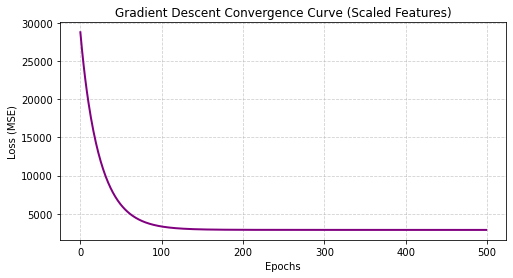

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(range(obj.epochs), obj.loss_history, color='purple', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Gradient Descent Convergence Curve (Scaled Features)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Model Performance Comparasion

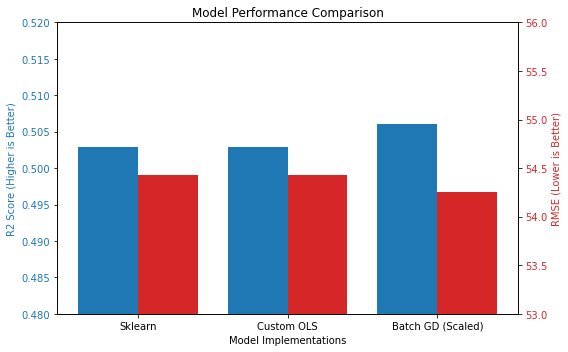

In [15]:

# Data from your actual notebook results
models = ['Sklearn', 'Custom OLS', 'Batch GD (Scaled)']
r2_scores = [r2_score_sk, r2_score_ols, r2_score_bgr]
rmse_values = [rmse_sk, rmse_ols, rmse_bgr]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot R2 Score (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('Model Implementations')
ax1.set_ylabel('R2 Score (Higher is Better)', color=color)
bars1 = ax1.bar(np.arange(len(models)) - 0.2, r2_scores, width=0.4, color=color, label='R2 Score')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.48, 0.52) # Zoom in to see the slight differences!

# Plot RMSE (Right Axis)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('RMSE (Lower is Better)', color=color)
bars2 = ax2.bar(np.arange(len(models)) + 0.2, rmse_values, width=0.4, color=color, label='RMSE')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(53, 56)

plt.xticks(np.arange(len(models)), models)
plt.title('Model Performance Comparison')
fig.tight_layout()
plt.show()

# Conclusion

In this project, I successfully implemented Ordinary Least Squares (OLS) and Batch Gradient Descent from scratch in Python to predict diabetes progression, benchmarking them against Scikit-Learn's production-ready LinearRegression model.

